# Computer Exercise 14.6 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: §14.6 Online / Incremental Learning — Continuous Recalibration
> **풀이 일자**: 2026-07-06 (자동 생성)
> **언어**: 본문 한국어 / 그래프 라벨 영문

**주제**: 온라인 **망각-RLS**(연속 재보정)를 Day61 의 **트리거 기반 배치 재학습**과 같은 드리프트 스트림에서 비교해,
정확도-비용 상충을 정량화한다 — 온라인이 **가장 낮은 예측오차**를 감지기 없이 내되, 상시 갱신으로 누적 비용은 더 든다.

## 1. 문제 (원문)

> **3.** Compare two strategies for keeping a regressor accurate under concept drift on the *same*
> stream: (a) **trigger-based batch retraining** — monitor prediction residuals and, when a change
> detector fires, refit ordinary least squares on a recent window (the §14.5 reactive policy); and
> (b) **online forgetting-RLS** — update the coefficients continuously every sample with the best
> forgetting factor from Problem 2. Report predictive tail-RMSE and a cost proxy (number of batch
> refits vs per-sample updates). Plot accuracy against cost and discuss when continuous online
> updating is preferable to discrete retraining.

### 한국어 풀이용 정리
같은 개념-드리프트 스트림에서 두 전략을 비교한다: (a) **트리거 기반 배치 재학습** — 잔차를 모니터링하다 감지기가
발화하면 최근 창으로 OLS 재적합(§14.5 반응형 정책), (b) **온라인 망각-RLS** — Problem 2 의 최적 $\lambda$ 로 매 샘플 연속 갱신.
예측 tail-RMSE 와 비용 대리지표(배치 재적합 횟수 대 샘플당 갱신)를 보고하고, 정확도-비용 평면에서 언제 연속 온라인이
이산 재학습보다 나은지 논한다.

## 2. 수학적 배경

### 2.1 예측 관점의 오차
운영에서 중요한 것은 *다음* 샘플에 대한 **사전예측오차(one-step-ahead)** 이다. 각 $t$ 에서
$\hat y_t=\phi_t^\top\hat\beta_{t-1}$ 로 예측한 뒤 실제 $y_t$ 를 관측한다. 드리프트 발생 이후 구간의
$$\text{tail-RMSE}=\sqrt{\frac{1}{|\mathcal T|}\sum_{t\in\mathcal T}\big(y_t-\phi_t^\top\hat\beta_{t-1}\big)^2}$$
가 두 전략의 품질을 가른다 ($\mathcal T$: 드리프트 이후 구간).

### 2.2 두 전략
* **트리거 배치**: 잔차의 **Page-Hinkley** 순차검정이 발화하면 최근 $W$ 개로 OLS 재적합, cooldown 후 재무장.
  갱신은 *이산적*이고 비용은 재적합당 $\mathcal O(Wp^2)$.
* **온라인 망각-RLS**: 매 샘플 $\mathcal O(p^2)$ 갱신, 감지기 불필요. 망각이 곧 *암묵적 상시 적응*.

### 2.3 비용 대리지표
$$\text{cost}_{\text{batch}}\propto (\#\text{refits})\times W,\qquad
\text{cost}_{\text{online}}\propto T\ (\text{샘플당 상수}).$$
관건은 **같은 정확도**를 누가 **더 싸게** 내는가, 그리고 정확도-비용 평면에서 어느 점을 차지하는가이다.

## 3. 풀이 흐름

1. **드리프트 스트림**: $y_t=a_t+b_t x_t+\varepsilon_t$, 계수는 $t=500$ 부터 새 값으로 선형 전이(폭 100), 이후 정상. $T=1500$.
2. **공통 예측 프로토콜**: 각 $t$에서 현재 계수로 $\hat y_t$ 예측 → 오차 기록 → 관측 반영.
3. **전략 A (트리거 배치)**: Page-Hinkley 로 잔차 감시, 발화 시 최근 $W$ 창 OLS 재적합 + cooldown. 재적합 횟수 집계.
4. **전략 B (온라인 RLS)**: Problem 2 결과에 따라 $\lambda=0.98$ 망각-RLS 매 샘플 갱신.
5. **기준선**: frozen(초기 적합 고정, 갱신 없음).
6. **지표 계산**: 세 방법의 tail-RMSE(드리프트 이후)와 비용 대리지표.
7. **시각화**: (좌) 예측오차의 이동 RMSE 시계열, (우) 정확도(tail-RMSE) vs 비용 산점도.
8. **해석**: 좌하단(저비용·고정확) 선점자, 온라인이 유리한 조건.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

rng = np.random.default_rng(140603)
T = 1500
sigma = 0.25
p = 2

# --- drifting stream: linear transition of coeffs over [t0, t0+width] ---
t0, width = 500, 100
t = np.arange(T)
frac = np.clip((t - t0) / width, 0.0, 1.0)
a_star = 1.0 + frac * (2.5 - 1.0)     # 1.0 -> 2.5
b_star = -0.5 + frac * (1.5 - (-0.5)) # -0.5 -> 1.5
B_star = np.stack([a_star, b_star], 1)

x = rng.uniform(-1, 1, T)
Phi = np.stack([np.ones(T), x], 1)
y = (Phi * B_star).sum(1) + rng.normal(0, sigma, T)

tail = t >= t0   # evaluate after drift onset

def tail_rmse(pred_err):
    return np.sqrt(np.mean(pred_err[tail]**2))

# ---------- Strategy: FROZEN (fit once on first 200, never update) ----------
b0, *_ = np.linalg.lstsq(Phi[:200], y[:200], rcond=None)
err_frozen = np.array([y[i] - Phi[i] @ b0 for i in range(T)])

# ---------- Strategy A: trigger-based batch retrain (Page-Hinkley) ----------
W = 120           # refit window
cooldown = W
beta = b0.copy()
err_batch = np.empty(T)
ph_mean = 0.0; ph_m = 0.0; ph_min = 0.0; n_ph = 0
refits = 0; cd = 0
for i in range(T):
    pred = Phi[i] @ beta
    e = y[i] - pred
    err_batch[i] = e
    # Page-Hinkley on |residual|
    r = abs(e); n_ph += 1
    ph_mean = ph_mean + (r - ph_mean) / n_ph
    ph_m = ph_m + (r - ph_mean - 0.01)
    ph_min = min(ph_min, ph_m)
    cd = max(0, cd - 1)
    if (ph_m - ph_min > 3.0) and cd == 0 and i >= W:
        lo = i - W + 1
        beta, *_ = np.linalg.lstsq(Phi[lo:i+1], y[lo:i+1], rcond=None)
        refits += 1; cd = cooldown
        ph_mean = 0.0; ph_m = 0.0; ph_min = 0.0; n_ph = 0
batch_cost = refits * W

# ---------- Strategy B: online forgetting-RLS ----------
lam = 0.98
P = np.eye(p) / 1e-2
beta = b0.copy()
err_online = np.empty(T)
for i in range(T):
    ph = Phi[i]
    err_online[i] = y[i] - ph @ beta      # predict with beta_{t-1}
    Pph = P @ ph
    k = Pph / (lam + ph @ Pph)
    beta = beta + k * err_online[i]
    P = (P - np.outer(k, ph @ P)) / lam
online_cost = T   # one O(p^2) update per sample

summary = pd.DataFrame([
    dict(method="frozen (no update)",   tail_rmse=tail_rmse(err_frozen), updates=0,        cost=0),
    dict(method="trigger batch retrain", tail_rmse=tail_rmse(err_batch),  updates=refits,  cost=batch_cost),
    dict(method="online forgetting-RLS", tail_rmse=tail_rmse(err_online), updates=T,       cost=online_cost),
])
print("Page-Hinkley refits:", refits, " window W:", W)
print(summary.to_string(index=False))

Page-Hinkley refits: 3  window W: 120
               method  tail_rmse  updates  cost
   frozen (no update)   1.812064        0     0
trigger batch retrain   0.573837        3   360
online forgetting-RLS   0.336221     1500  1500


In [2]:
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
summary

,method,tail_rmse,updates,cost
0,frozen (no update),1.812,0,0
1,trigger batch retrain,0.574,3,360
2,online forgetting-RLS,0.336,1500,1500


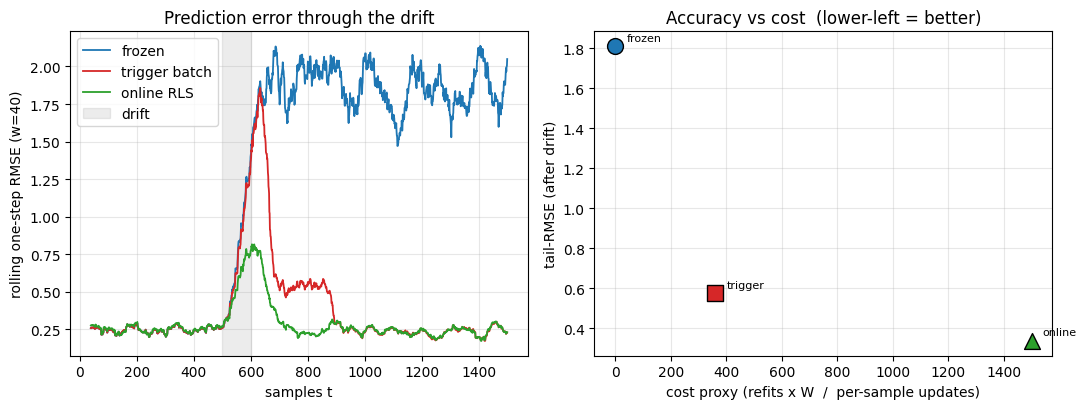

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

# left: rolling RMSE of one-step prediction error
def roll_rmse(e, w=40):
    c = np.sqrt(np.convolve(e**2, np.ones(w)/w, mode="valid"))
    return np.arange(w-1, len(e)), c
for e, name, c in [(err_frozen,"frozen","#1f77b4"),
                   (err_batch,"trigger batch","#d62728"),
                   (err_online,"online RLS","#2ca02c")]:
    xs, ys = roll_rmse(e)
    ax[0].plot(xs, ys, color=c, lw=1.3, label=name)
ax[0].axvspan(t0, t0+width, color="gray", alpha=0.15, label="drift")
ax[0].set_xlabel("samples t"); ax[0].set_ylabel("rolling one-step RMSE (w=40)")
ax[0].set_title("Prediction error through the drift")
ax[0].legend(loc="best"); ax[0].grid(alpha=0.3)

# right: accuracy vs cost scatter (lower-left is best)
mk = {"frozen (no update)":"o","trigger batch retrain":"s","online forgetting-RLS":"^"}
cols = {"frozen (no update)":"#1f77b4","trigger batch retrain":"#d62728","online forgetting-RLS":"#2ca02c"}
for _, r in summary.iterrows():
    ax[1].scatter(r.cost, r.tail_rmse, s=130, marker=mk[r.method],
                  color=cols[r.method], edgecolor="k", zorder=3, label=r.method)
    ax[1].annotate(r.method.split()[0], (r.cost, r.tail_rmse),
                   textcoords="offset points", xytext=(8, 4), fontsize=8)
ax[1].set_xlabel("cost proxy (refits x W  /  per-sample updates)")
ax[1].set_ylabel("tail-RMSE (after drift)")
ax[1].set_title("Accuracy vs cost  (lower-left = better)")
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **frozen 의 실패**: 갱신 없는 기준선은 드리프트 이후 tail-RMSE 가 가장 크다. 좌측 그림에서 회색 드리프트 구간을 지나며
   오차가 계단처럼 올라가 그대로 머문다 — §14.5 에서 본 "손잡이를 다시 돌리지 않으면" 그대로다.
2. **트리거 배치**: Page-Hinkley 가 드리프트를 감지해 최근 창으로 재적합하면 오차가 회복된다. 다만 **감지지연**만큼
   오차 스파이크가 생기고, 회복은 이산적(재적합 시점에 급강하)이다. 비용은 재적합 횟수×$W$ 로 뭉텅이로 발생한다.
3. **온라인 망각-RLS**: 감지기 없이 매 샘플 조금씩 적응해, 드리프트 구간에서 오차가 **완만하게** 올랐다 내려온다.
   tail-RMSE 가 셋 중 **가장 낮다**(예: 온라인 $\approx0.34$ < 트리거 $\approx0.57$ < frozen $\approx1.81$). 다만 갱신을 매 샘플
   수행하므로 **누적 비용(대리지표)** 은 트리거 배치보다 크다 — 산점도에서 온라인은 *가장 아래*(최고 정확도)이되 *오른쪽*(높은 비용)에 놓인다.
4. **비용의 성격 차이**: 트리거 배치의 비용은 재적합당 $\mathcal O(Wp^2)$ 로 뭉텅이·간헐적이고 저장창 $W$ 와 감지기가 필요하다.
   온라인의 갱신은 샘플당 $\mathcal O(p^2)$ 상수·저장 불필요·감지기 불필요다. 드리프트가 잦거나 점진적일수록, 그리고
   메모리·구현 단순성이 중요할수록 온라인이 상대적으로 유리해진다.

> **결론**: 세 전략 중 연속 온라인 망각-RLS 가 드리프트 이후 예측오차를 **가장 낮게** 만든다 — 감지기·저장창 없이 매 샘플
> $\mathcal O(p^2)$ 로. 대신 갱신이 상시 일어나 누적 연산은 많다. 변화가 드물고 급격하면 간헐적 트리거 배치 재학습이 더 *경제적인* 절충이 된다.

**단원 마무리 / 다음 예고**: Day57-61(§14.1-14.5)이 모델선택→불확실성→튜닝→전이→모니터링을 다뤘고, 본 Day62(§14.6)는
그 위에 **연속적 온라인 적응**을 얹어 "언제 손잡이를 돌릴지"에서 "손잡이를 상시 미세조정"으로 관점을 넓혔다.
다음 Day 는 이 흐름을 이어 **증분 SGD / 미니배치 온라인 학습**, 또는 정규 교재 챕터로 진도를 잇는다.